# Libraries

In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
from sklearn.neural_network import MLPRegressor

# Model upload

In [7]:
name_best_model = 'models/model_NeuralNetwork_MLP_fold_4.pkl'
model = joblib.load(name_best_model)

# Profile

##### **a. Type of Cement**

| Code | Description |
| :---: | :--- |
| **0** | CPII Z |
| **1** | CPV - ARI |
| **2** | CPIV |
| **3** | CPII F |
| **4** | CPIII |
| **5** | CPII E |

##### **b. Exposure Conditions**

| Code | Description |
| :---: | :--- |
| **0** | PIA (Internal Protected) |
| **1** | UEA (External Unprotected) |
| **2** | PEA (External Protected) |

In [8]:
CO2_ppm = 500               # Change as you wish. In ppm units        
fc = 25                     # Change as you wish. In MPa units 
rh = 70                     # Change as you wish. In % units
cement_type = 3             # Change as you wish. 0 to 5.
exposure_conditions = 2     # Change as you wish. 0 to 2.

In [9]:
df = {'t (years)': list(range(1, 101))}
df = pd.DataFrame(df)
df['CO2 (%)'] = CO2_ppm / 10000
df['fc (MPa)'] = fc
df['RH (%)'] = np.random.normal(rh, 0.1*rh, 100)
df['Type of cement'] = cement_type
df['Exposure conditions'] = exposure_conditions
expected_order = list(model.feature_names_in_)
df = df[expected_order]
df

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years)
0,0.05,25,76.014570,3,2,1
1,0.05,25,62.250393,3,2,2
2,0.05,25,69.190271,3,2,3
3,0.05,25,73.345172,3,2,4
4,0.05,25,71.491957,3,2,5
...,...,...,...,...,...,...
95,0.05,25,63.441347,3,2,96
96,0.05,25,71.100258,3,2,97
97,0.05,25,63.086116,3,2,98
98,0.05,25,71.888201,3,2,99


### Creating profile

In [12]:
df_aux = df.copy()
y_pred = model.predict(df)
df_aux['carb. depth (mm)'] = list(y_pred)
df_aux['carb. depth (mm)'] = df_aux['carb. depth (mm)'].cummax()
df_aux

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),carb. depth (mm)
0,0.05,25,76.014570,3,2,1,2.862527
1,0.05,25,62.250393,3,2,2,4.641953
2,0.05,25,69.190271,3,2,3,6.218375
3,0.05,25,73.345172,3,2,4,6.352488
4,0.05,25,71.491957,3,2,5,7.255145
...,...,...,...,...,...,...,...
95,0.05,25,63.441347,3,2,96,39.200361
96,0.05,25,71.100258,3,2,97,39.200361
97,0.05,25,63.086116,3,2,98,39.758071
98,0.05,25,71.888201,3,2,99,39.758071


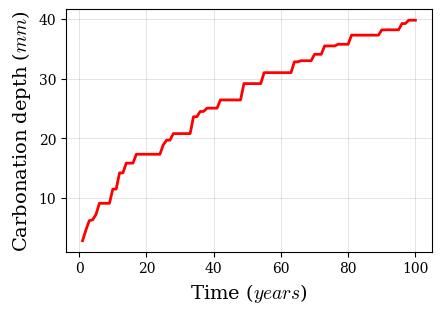

In [11]:
# Figure name and DPI
dpi = 600                                                       # Change as you wish
name = 'carbonation_profile'                                    # Change as you wish

# Chart dimensions (in centimeters)
b_cm = 12                                                       # Change as you wish
h_cm = 8                                                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# Axis and labels 
label_x = 'Time ($years$)'                                      # Change as you wish
label_y = 'Carbonation depth ($mm$)'                            # Change as you wish
size_label = 14                                                 # Change as you wish
color_label = 'black'                                           # or hexadecimal. Change as you wish
size_axis = 10                                                  # Change as you wish
color_axis = 'black'                                            # or hexadecimal. Change as you wish

# Line
size_line = 2                                                   # Change as you wish
style_line = '-'                                                # Change as you wish
color_line = 'red'                                              # or hexadecimal. Change as you wish

# Marker
marker = None                                                   # Change as you wish
size_marker = 4                                                 # Change as you wish
color_marker = 'black'                                          # or hexadecimal. Change as you wish
color_marker_edge = color_line                                  # Change as you wish

# Legend
labels_legend = 'Carbonation Profile'                           # Change as you wish
size_legend = 10                                                # Change as you wish
location_legend = 'lower left'                                  # Change as you wish - 'best' look up by the best fit

# Grid
on_or_off = True
line_width_grid = 0.5                                           # Change as you wish
alpha_grid = 0.3                                                # Change as you wish
style_grid = '-'                                                # Change as you wish
color_grid = 'gray'                                             # or hexadecimal. Change as you wish

# Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Title
# ax.set_title('Sine Wave Plot', fontsize=16)

# Config grid
plt.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)

### Plot data and legend
ax.plot(df_aux['t (years)'], df_aux['carb. depth (mm)'], 
         markerfacecolor=color_marker, marker=marker, markersize=size_marker,
         linewidth=size_line, linestyle=style_line, color=color_line,
         label=labels_legend)
# ax.legend(fontsize=size_legend, loc=location_legend)

# Save
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()